## Project 1: Machine Learning Methods - ObesityDataSet

### From Hank

#### How can we use health measurements to predict obesity
The dataset provided has two forms of direct/indirect obesity measures. The first is a categorisation (NObeyesdad). 
NObesity values are:
- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

The second can be done directly via Body Mass Index (BMI) which can be derived from height and weight (use your magical Google skills to find the formula).

The goal here is to do some data modelling to achieve the following:
- What recommendations would you make to the public to reduce the rate of obesity (backed by evidence)?

#### Metric Descriptions

Other provided metrics include:
Gender, Age

The attributes related with eating habits are: 
- Frequent consumption of high caloric food (FAVC)
- Frequency of consumption of vegetables (FCVC)
- Number of main meals (NCP)
- Consumption of food between meals (CAEC)
- Consumption of water daily (CH20)
- Consumption of alcohol (CALC).

The attributes related with the physical condition are: 
- Calories consumption monitoring (SCC)
- Physical activity frequency (FAF)
- Time using technology devices (TUE)
- Transportation used (MTRANS)

### 1. Read the dataset

In [1]:
import pandas as pd

# Load the dataset
file_path = 'ObesityDataSet.csv'  
obesity_data = pd.read_csv(file_path)

# Display the first few rows of the dataset
obesity_data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 2. Analyse and visualise the data

Shape: (2111, 17)
Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: NObeyesdad, dtype: int64


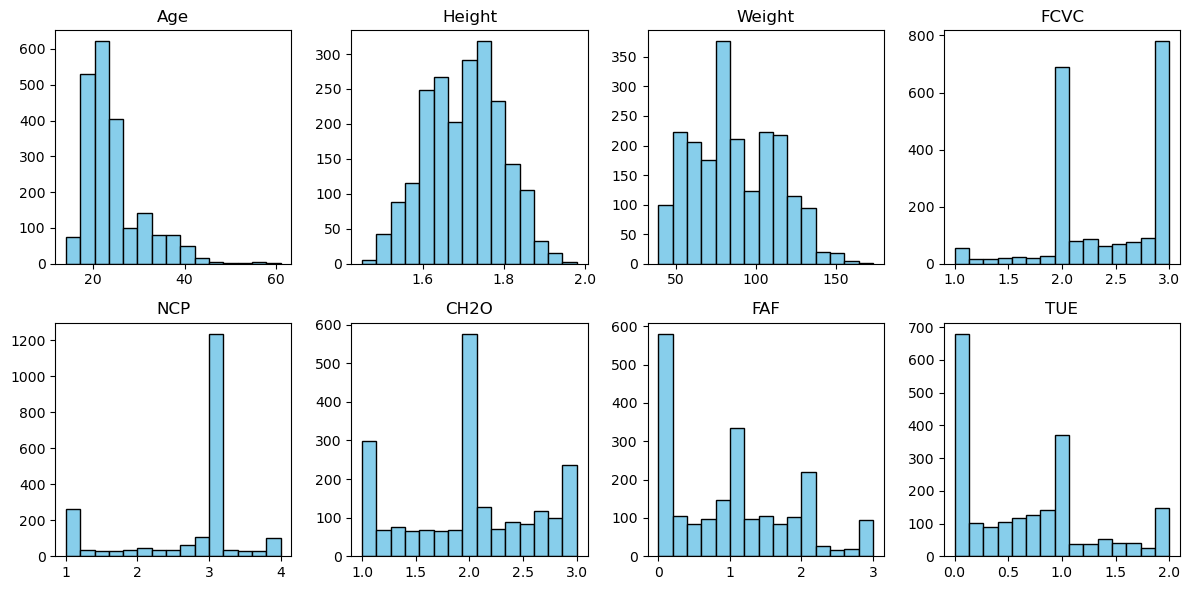

In [2]:

"""Use the code to check the categorical label indicating the obesity level of the person  """
import pandas as pd
df = pd.read_csv("ObesityDataSet.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df['NObeyesdad'].value_counts())
df.head(5)


"""
We plot histograms for the numeric features to inspect their distributions:
The numeric features include Age, Height, Weight, and other diet or physical activity metrics such as FCVC, NCP, CH2O, FAF, TUE
"""
import matplotlib.pyplot as plt
numeric_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=15, color='skyblue', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

Gender value counts:
Male      1068
Female    1043
Name: Gender, dtype: int64 

family_history_with_overweight value counts:
yes    1726
no      385
Name: family_history_with_overweight, dtype: int64 

FAVC value counts:
yes    1866
no      245
Name: FAVC, dtype: int64 

CAEC value counts:
Sometimes     1765
Frequently     242
Always          53
no              51
Name: CAEC, dtype: int64 

SMOKE value counts:
no     2067
yes      44
Name: SMOKE, dtype: int64 

SCC value counts:
no     2015
yes      96
Name: SCC, dtype: int64 

CALC value counts:
Sometimes     1401
no             639
Frequently      70
Always           1
Name: CALC, dtype: int64 

MTRANS value counts:
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: MTRANS, dtype: int64 



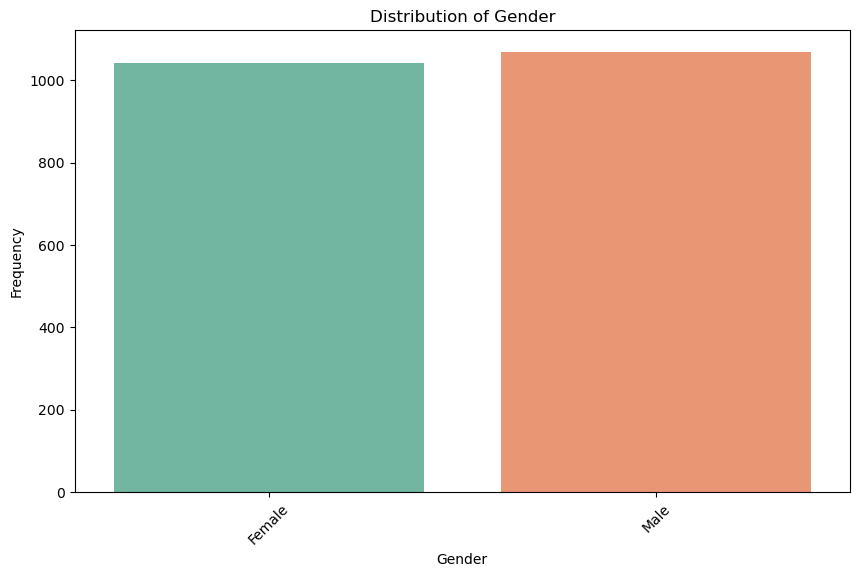

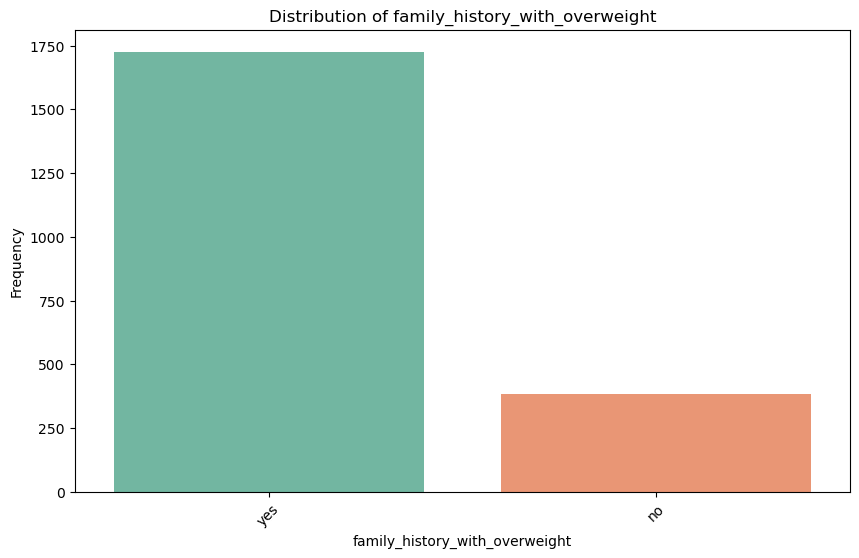

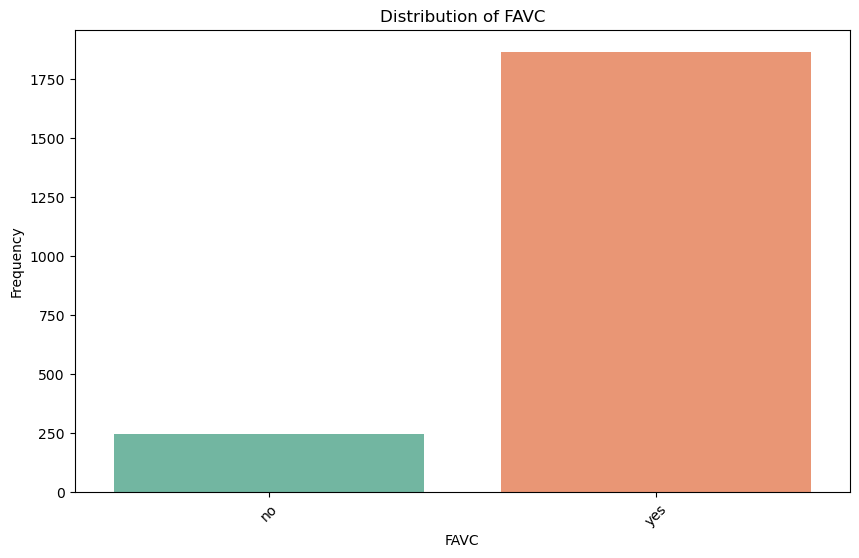

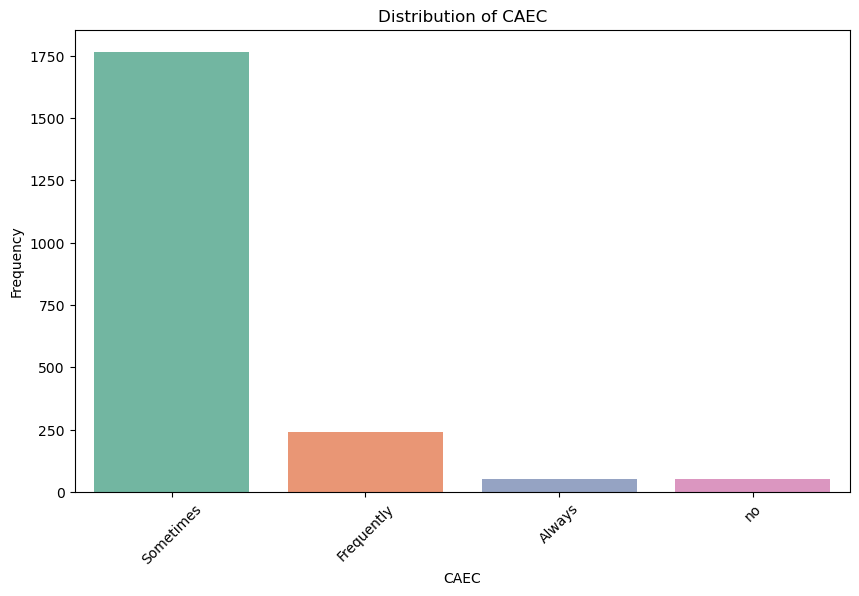

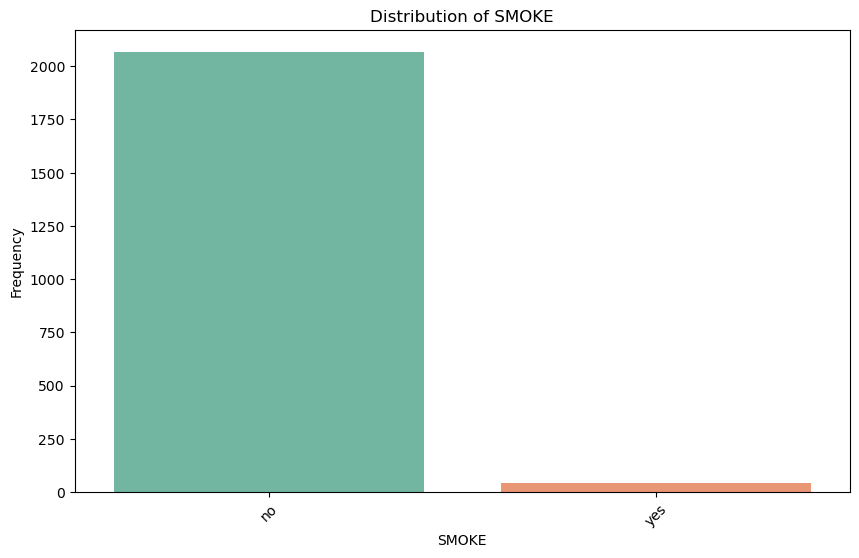

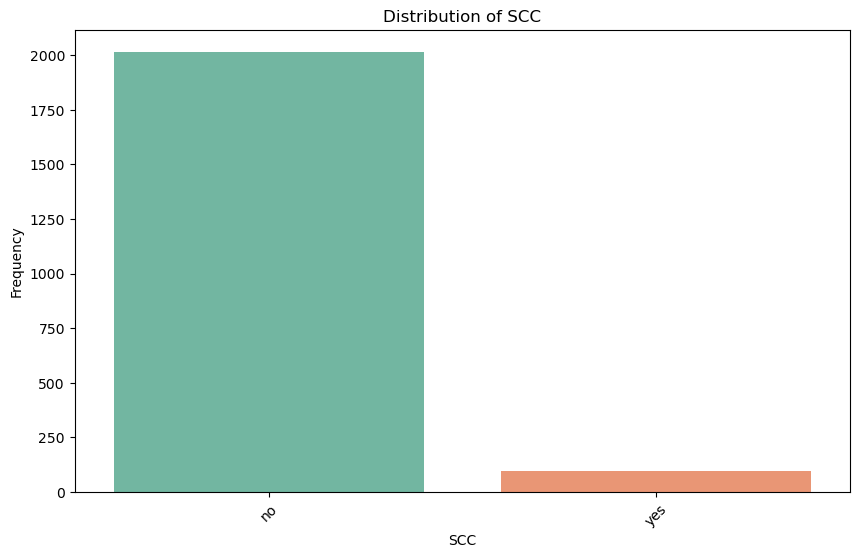

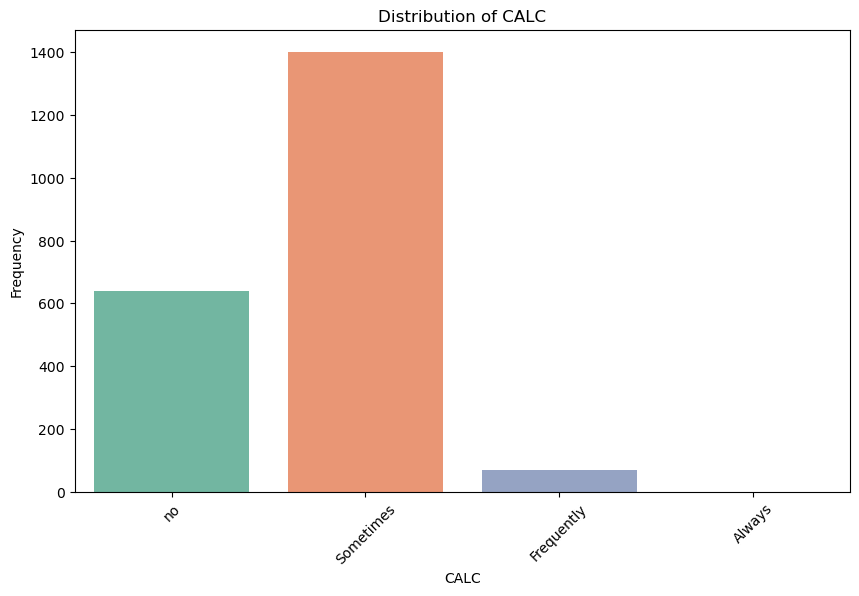

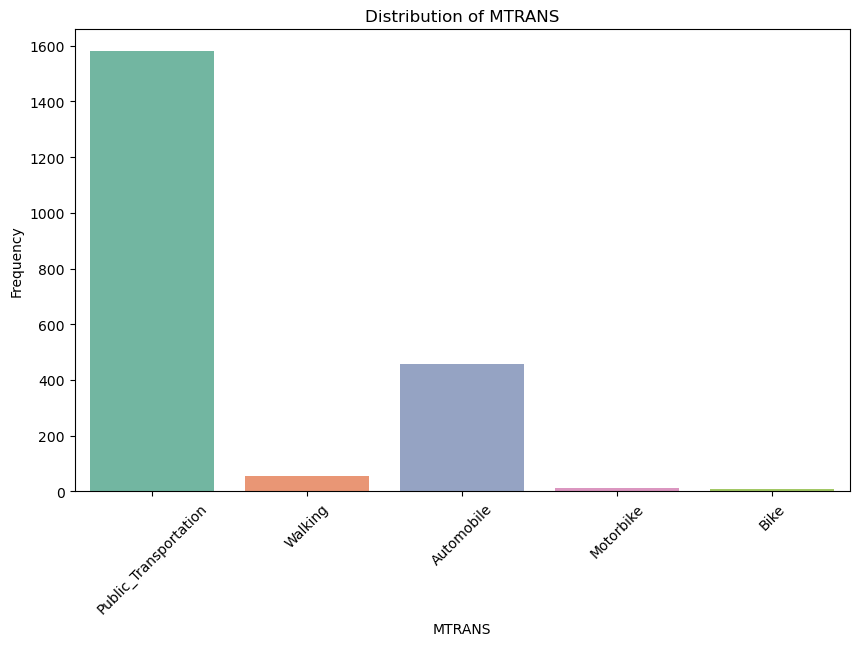

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Gender','family_history_with_overweight','FAVC','CAEC',
                    'SMOKE','SCC','CALC','MTRANS']
for col in categorical_cols:
    print(col, "value counts:")
    print(df[col].value_counts(), "\n")

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=obesity_data, x=col, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()


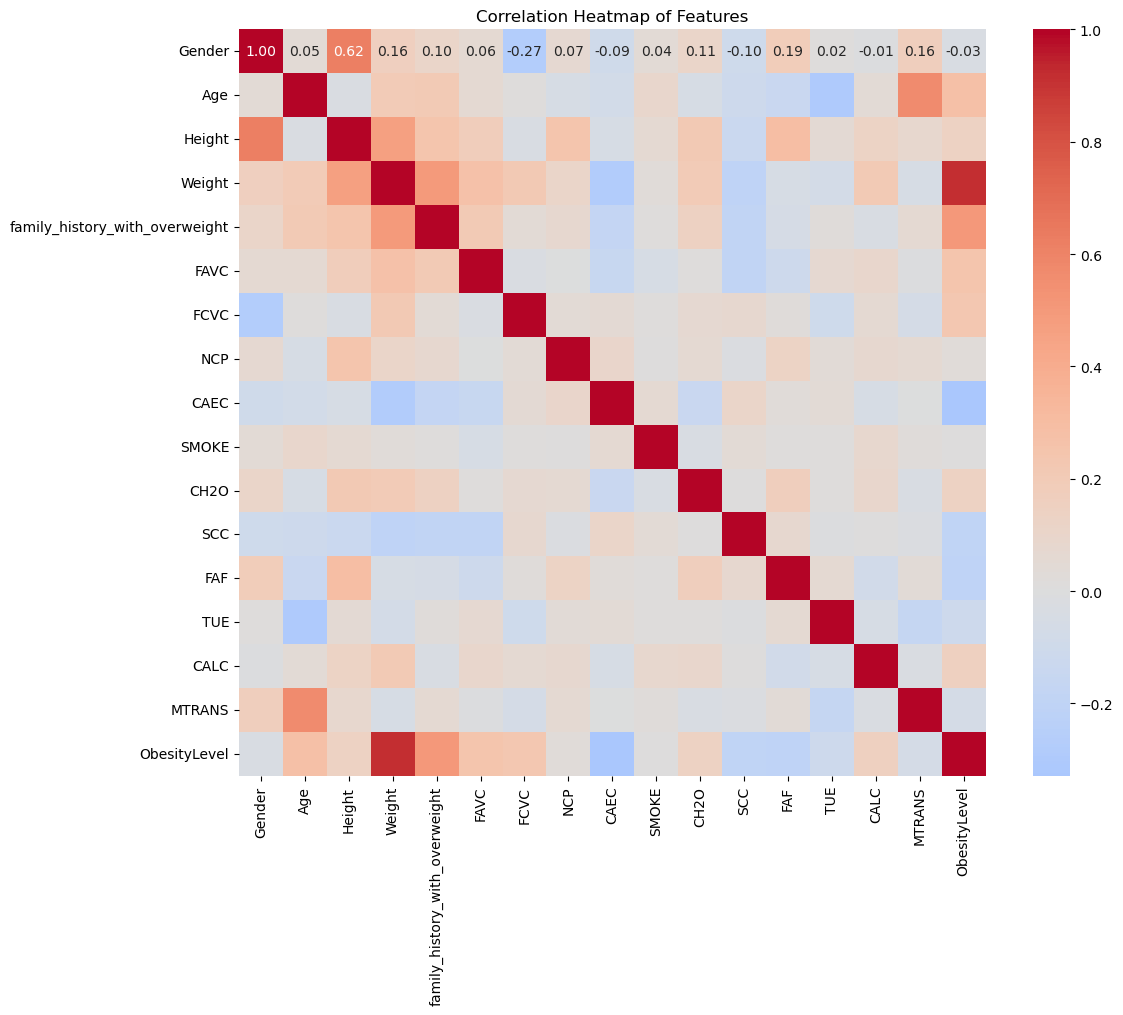

In [4]:
'''
This part is make a heatmap to show the relationship between each feature.
The correlation matrix is visualized using a heatmap. In the heatmap, each cell shows the correlation coefficient between two features. 
Values closer to 1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship. 
The color map helps readers identify these relationships more easily, with warm colors representing positive correlations and cool colors representing negative correlations.
'''


# Create a copy of the dataframe for correlation analysis
corr_df = obesity_data.copy()


# Encoding categorical columns
corr_df['Gender'] = corr_df['Gender'].map({'Female': 0, 'Male': 1})
corr_df['family_history_with_overweight'] = corr_df['family_history_with_overweight'].map({'no': 0, 'yes': 1})
corr_df['FAVC'] = corr_df['FAVC'].map({'no': 0, 'yes': 1})
corr_df['SMOKE'] = corr_df['SMOKE'].map({'no': 0, 'yes': 1})
corr_df['SCC'] = corr_df['SCC'].map({'no': 0, 'yes': 1})
corr_df['CAEC'] = corr_df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
corr_df['CALC'] = corr_df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
corr_df['MTRANS'] = corr_df['MTRANS'].map({
    'Public_Transportation': 0, 'Walking': 1, 'Automobile': 2, 'Motorbike': 3, 'Bike': 4
})
corr_df['ObesityLevel'] = corr_df['NObeyesdad'].map({
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
})


# Drop the original target column
corr_df = corr_df.drop('NObeyesdad', axis=1)

# Calculate the correlation matrix
corr_matrix = corr_df.corr()


# Plot the correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    center=0,
    square=True
)
plt.title("Correlation Heatmap of Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
print(corr_matrix.loc['Gender', 'Age'])
print(corr_matrix.loc['Age', 'Gender'])
print(corr_matrix.loc['Gender', 'Age'] - corr_matrix.loc['Age', 'Gender'])
print((corr_matrix - corr_matrix.T).abs().sum().sum())

0.04839419676758287
0.04839419676758287
0.0
0.0


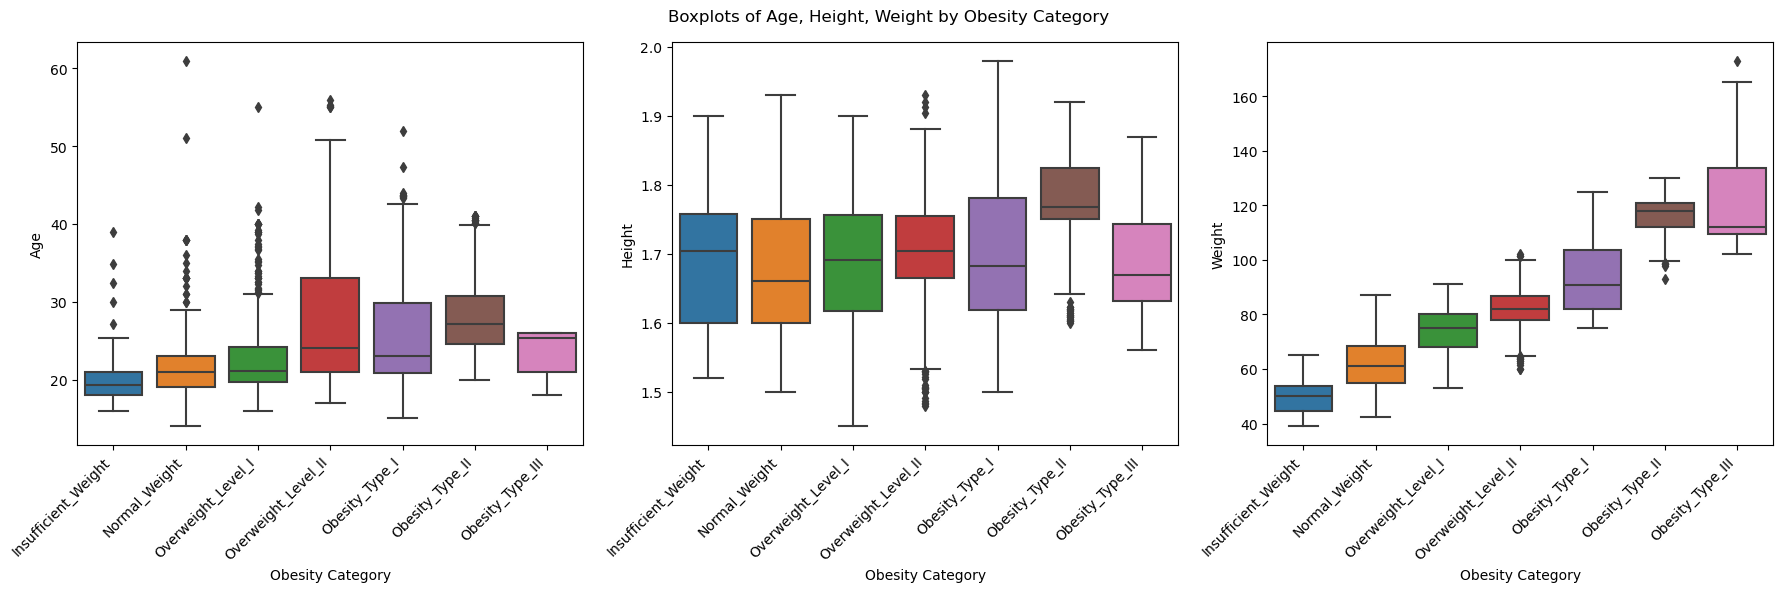

In [6]:
"""
This section uses boxplots to compare the distributions of Age, Height, and Weight
across different obesity categories.

The obesity categories are displayed in a fixed order so that the progression
from underweight to severe obesity is easier to interpret. Each boxplot shows
the median, spread, and possible outliers of the feature within each category,
helping readers identify differences and trends among obesity groups.
"""

import seaborn as sns
# Define the order of the fat rank
order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
         'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

# Make the side of the picture
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Draw the boxplot into three feature include age, height, weight
# The X-asis use the fat rank in the data
sns.boxplot(x='NObeyesdad', y='Age', data=df, order=order, ax=axes[0])
sns.boxplot(x='NObeyesdad', y='Height', data=df, order=order, ax=axes[1])
sns.boxplot(x='NObeyesdad', y='Weight', data=df, order=order, ax=axes[2])

# Unify the adjustment of x-axis labels that is easier to read
for ax in axes:
    ax.set_xlabel('Obesity Category')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.suptitle('Boxplots of Age, Height, Weight by Obesity Category')
plt.tight_layout()
plt.show()

### 3. Organise the data for modelling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
target_mapping = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
df['TargetCode'] = df['NObeyesdad'].map(target_mapping)  # encode target
X = df.drop(['NObeyesdad', 'TargetCode'], axis=1)
y = df['TargetCode']

# Define categorical and numeric feature lists
categorical_cols = ['Gender','family_history_with_overweight','FAVC','CAEC',
                    'SMOKE','SCC','CALC','MTRANS']
numeric_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

# divide the dataset into the train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

# One-hot encode categorical features
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

# Scale numeric features using training set stats
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

# Reassemble processed feature sets
import numpy as np
X_train_proc = np.hstack([X_train_num, X_train_cat])
X_test_proc = np.hstack([X_test_num, X_test_cat])
print("Training set shape:", X_train_proc.shape)
print("Test set shape:", X_test_proc.shape)

Training set shape: (1688, 23)
Test set shape: (423, 23)


### 4. Implement prediction models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Instantiate the models
logreg = LogisticRegression(max_iter=1000, random_state=0)
rf = RandomForestClassifier(n_estimators=100, random_state=0)

### 5. Train prediction models

In [10]:
# Train the models on the training set
logreg.fit(X_train_proc, y_train)
rf.fit(X_train_proc, y_train)

print("Training accuracy (Logistic):", logreg.score(X_train_proc, y_train))
print("Training accuracy (Random Forest):", rf.score(X_train_proc, y_train))

Training accuracy (Logistic): 0.9052132701421801
Training accuracy (Random Forest): 1.0


### 6. Test prediction models and show results

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test set
y_pred_log = logreg.predict(X_test_proc)
y_pred_rf = rf.predict(X_test_proc)

# Overall accuracy
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Logistic Regression accuracy: %.3f" % acc_log)
print("Random Forest accuracy: %.3f" % acc_rf)

# Detailed classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=list(target_mapping.keys())))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=list(target_mapping.keys())))


Logistic Regression accuracy: 0.898
Random Forest accuracy: 0.962
Logistic Regression Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.98      0.95        54
      Normal_Weight       0.96      0.76      0.85        58
 Overweight_Level_I       0.79      0.86      0.83        58
Overweight_Level_II       0.80      0.78      0.79        58
     Obesity_Type_I       0.90      0.93      0.92        70
    Obesity_Type_II       0.91      0.98      0.94        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       weighted avg       0.90      0.90      0.90       423

Random Forest Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        54
      Normal_Weight       0.86      0.93      0.89       